### Importing libraries.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

### Fetching the raw student score dataset in JSON format from the Sling Academy API.

In [2]:
url = "https://api.slingacademy.com/v1/sample-data/files/student-scores.json"
response = requests.get(url)
response.raise_for_status()
data = response.json()
print("Data fetched successfully!")

Data fetched successfully!


### Printing the raw JSON data fetched from the API response just to check.

In [3]:
print(data)

[{'id': 1, 'first_name': 'Paul', 'last_name': 'Casey', 'email': 'paul.casey.1@gslingacademy.com', 'gender': 'male', 'part_time_job': False, 'absence_days': 3, 'extracurricular_activities': False, 'weekly_self_study_hours': 27, 'career_aspiration': 'Lawyer', 'math_score': 73, 'history_score': 81, 'physics_score': 93, 'chemistry_score': 97, 'biology_score': 63, 'english_score': 80, 'geography_score': 87}, {'id': 2, 'first_name': 'Danielle', 'last_name': 'Sandoval', 'email': 'danielle.sandoval.2@gslingacademy.com', 'gender': 'female', 'part_time_job': False, 'absence_days': 2, 'extracurricular_activities': False, 'weekly_self_study_hours': 47, 'career_aspiration': 'Doctor', 'math_score': 90, 'history_score': 86, 'physics_score': 96, 'chemistry_score': 100, 'biology_score': 90, 'english_score': 88, 'geography_score': 90}, {'id': 3, 'first_name': 'Tina', 'last_name': 'Andrews', 'email': 'tina.andrews.3@gslingacademy.com', 'gender': 'female', 'part_time_job': False, 'absence_days': 9, 'extra

### Loading the student JSON data into a pandas DataFrame

In [5]:
df = pd.DataFrame(data)

df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


### Calculating and printing the overall average score across all subjects and all students.

In [7]:
# Selected columns ending with '_score' and compute the overall mean
score_cols = [col for col in df.columns if col.endswith('_score')]
average_score = df[score_cols].mean().mean()

print(f"Average Overall Score: {average_score:.2f}")

Average Overall Score: 80.98


### Computing individual average score aand plotting the top 10 students' scores.

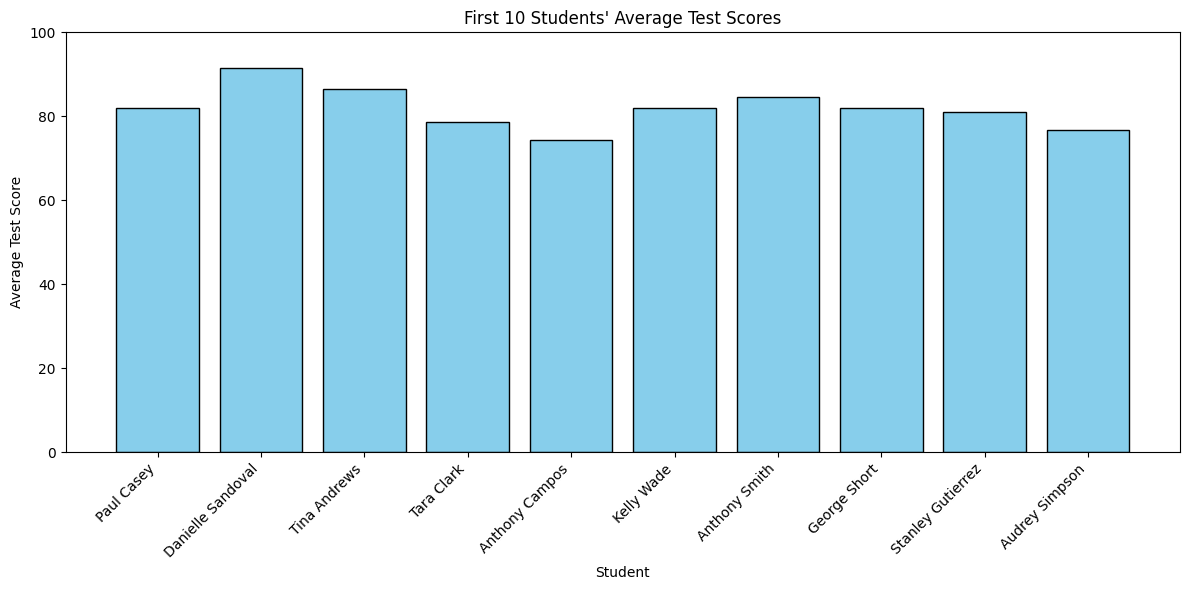

In [9]:
# 1. Created a 'name' column by combining first_name and last_name
df['name'] = df['first_name'] + ' ' + df['last_name']

# 2. Identifying the score columns and computing row-wise average_score
score_cols = [col for col in df.columns if col.endswith('_score')]
df['average_score'] = df[score_cols].mean(axis=1)

# 3. Plotting the average scores for the first 10 students for readability
plt.figure(figsize=(12, 6))

# Using the first 10 students for a clean visualization
df_subset = df.head(10)
plt.bar(df_subset["name"], df_subset["average_score"], color='skyblue', edgecolor='black')

plt.xlabel("Student")
plt.ylabel("Average Test Score")
plt.title("First 10 Students' Average Test Scores")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()

plt.show()